<a href="https://colab.research.google.com/github/folguedothalita-ai/thalita_folguedo2/blob/main/Tech_challeeng_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import io

# Read the Excel file, ensuring no header is automatically picked up
df_raw = pd.read_excel("Dados Históricos - Ibovespa.xlsx", header=None)

# The first row contains the header string (e.g., 'Data,"Último",..."')
header_string = df_raw.iloc[0, 0]
# Split the header string by comma and remove any quotes to get proper column names
column_names = [col.strip('"') for col in header_string.split(',')]

# Join the data rows (excluding the header) into a single string,
# then use io.StringIO and pd.read_csv to parse as proper CSV.
# This is more robust for CSV-like data with potentially quoted fields.
data_csv_string = "\n".join(df_raw.iloc[1:, 0].astype(str).tolist())
df = pd.read_csv(io.StringIO(data_csv_string), header=None, names=column_names, sep=',')

print(df.head())
print(df.columns.tolist())

         Data   Último  Abertura   Máxima   Mínima    Vol.    Var%
0  02.04.2026  188.052   187.923  189.251  185.214   7,08B   0,05%
1  01.04.2026  187.953   187.463  189.131  187.256  10,56B   0,26%
2  31.03.2026  187.462   182.515  187.508  182.515  11,39B   2,71%
3  30.03.2026  182.514   181.561  184.414  181.559   7,70B   0,53%
4  27.03.2026  181.557   182.733  183.351  180.976   8,07B  -0,64%
['Data', 'Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%']


In [ ]:
df = df.rename(columns={
    "Data": "data",
    "Último": "ultimo",
    "Abertura": "abertura",
    "Máxima": "maxima",
    "Mínima": "minima",
    "Vol.": "vol",
    "Var%": "var"
})

In [ ]:
df = df.rename(columns={
    "Data": "data",
    "Último": "ultimo",
    "Abertura": "abertura",
    "Máxima": "maxima",
    "Mínima": "minima",
    "Vol.": "vol",
    "Var%": "var"
})

# converter data
df["data"] = pd.to_datetime(df["data"], dayfirst=True)

# função para converter números
def converter_numero(x):
    x = str(x).replace(".", "").replace(",", ".")
    try:
        return float(x)
    except:
        return np.nan

for col in ["ultimo", "abertura", "maxima", "minima"]:
    df[col] = df[col].apply(converter_numero)

# variação %
df["var"] = df["var"].astype(str).str.replace("%", "").str.replace(",", ".")
df["var"] = pd.to_numeric(df["var"], errors="coerce")

# volume
def converter_volume(v):
    v = str(v).replace(",", ".")
    if "B" in v:
        return float(v.replace("B", "")) * 1e9
    elif "M" in v:
        return float(v.replace("M", "")) * 1e6
    elif "K" in v:
        return float(v.replace("K", "")) * 1e3
    else:
        try:
            return float(v)
        except:
            return np.nan

df["vol"] = df["vol"].apply(converter_volume)

df = df.sort_values("data").reset_index(drop=True)

df.head()

,data,ultimo,abertura,maxima,minima,vol,var
0,2022-01-03,103922.0,104823.0,106125.0,103413.0,11130000.0,-0.86
1,2022-01-04,103514.0,103922.0,104276.0,103096.0,11490000.0,-0.39
2,2022-01-05,101006.0,103514.0,103514.0,10085.0,12880000.0,-2.42
3,2022-01-06,101561.0,101006.0,102235.0,1010.0,11750000.0,0.55
4,2022-01-07,102719.0,101561.0,102719.0,101104.0,11730000.0,1.14


In [ ]:
# retornos
df["ret_1"] = df["ultimo"].pct_change(1)
df["ret_3"] = df["ultimo"].pct_change(3)
df["ret_5"] = df["ultimo"].pct_change(5)
df["ret_10"] = df["ultimo"].pct_change(10)

# médias móveis
df["mm_5"] = df["ultimo"].rolling(5).mean()
df["mm_10"] = df["ultimo"].rolling(10).mean()
df["mm_20"] = df["ultimo"].rolling(20).mean()

# relação entre médias
df["mm_ratio_5_20"] = df["mm_5"] / df["mm_20"]

# volatilidade
df["vol_5"] = df["ret_1"].rolling(5).std()
df["vol_10"] = df["ret_1"].rolling(10).std()

# lags
df["lag_1"] = df["ultimo"].shift(1)
df["lag_2"] = df["ultimo"].shift(2)

# momentum
df["momentum_5"] = df["ultimo"] - df["ultimo"].shift(5)

# candle e amplitude
df["candle"] = df["ultimo"] - df["abertura"]
df["amplitude"] = df["maxima"] - df["minima"]

print(df.head())

        data    ultimo  abertura    maxima    minima         vol   var  \
0 2022-01-03  103922.0  104823.0  106125.0  103413.0  11130000.0 -0.86   
1 2022-01-04  103514.0  103922.0  104276.0  103096.0  11490000.0 -0.39   
2 2022-01-05  101006.0  103514.0  103514.0   10085.0  12880000.0 -2.42   
3 2022-01-06  101561.0  101006.0  102235.0    1010.0  11750000.0  0.55   
4 2022-01-07  102719.0  101561.0  102719.0  101104.0  11730000.0  1.14   

      ret_1     ret_3  ret_5  ...  mm_10  mm_20  mm_ratio_5_20  vol_5  vol_10  \
0       NaN       NaN    NaN  ...    NaN    NaN            NaN    NaN     NaN   
1 -0.003926       NaN    NaN  ...    NaN    NaN            NaN    NaN     NaN   
2 -0.024229       NaN    NaN  ...    NaN    NaN            NaN    NaN     NaN   
3  0.005495 -0.022719    NaN  ...    NaN    NaN            NaN    NaN     NaN   
4  0.011402 -0.007680    NaN  ...    NaN    NaN            NaN    NaN     NaN   

      lag_1     lag_2  momentum_5  candle  amplitude  
0       NaN  

In [ ]:
df["ret_futuro"] = df["ultimo"].shift(-1) / df["ultimo"] - 1

df["target"] = np.where(
    df["ret_futuro"] > 0.002, 1,
    np.where(df["ret_futuro"] < -0.002, 0, np.nan)
)

print(df[["data", "ultimo", "ret_futuro", "target"]].tail())

           data    ultimo  ret_futuro  target
1057 2026-03-27  181557.0    0.005271     1.0
1058 2026-03-30  182514.0    0.027110     1.0
1059 2026-03-31  187462.0    0.002619     1.0
1060 2026-04-01  187953.0    0.000527     NaN
1061 2026-04-02  188052.0         NaN     NaN


In [ ]:
df = df.dropna().reset_index(drop=True)

train = df.iloc[:-30].copy()
test = df.iloc[-30:].copy()

X_train = train.drop(columns=["data", "target", "ret_futuro"])
y_train = train["target"]

X_test = test.drop(columns=["data", "target", "ret_futuro"])
y_test = test["target"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (867, 21)
X_test: (30, 21)
y_train: (867,)
y_test: (30,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

In [ ]:
resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    resultados.append({
        "Modelo": nome,
        "Acurácia": acc
    })

    predicoes[nome] = y_pred

df_resultados = pd.DataFrame(resultados).sort_values("Acurácia", ascending=False)
print(df_resultados)

                Modelo  Acurácia
0  Regressão Logística       0.6
1        Random Forest       0.6
2              XGBoost       0.6


In [ ]:
melhor_modelo_nome = df_resultados.iloc[0]["Modelo"]
melhor_modelo = modelos[melhor_modelo_nome]
y_pred_best = predicoes[melhor_modelo_nome]

print("Melhor modelo:", melhor_modelo_nome)
print("Acurácia:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Melhor modelo: Regressão Logística
Acurácia: 0.6
              precision    recall  f1-score   support

         0.0       0.54      0.93      0.68        14
         1.0       0.83      0.31      0.45        16

    accuracy                           0.60        30
   macro avg       0.69      0.62      0.57        30
weighted avg       0.70      0.60      0.56        30



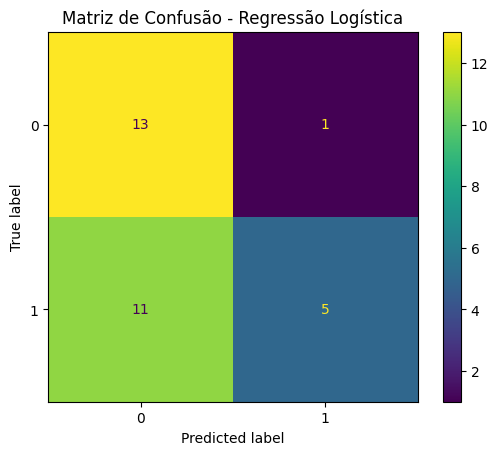

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de Confusão - {melhor_modelo_nome}")
plt.show()

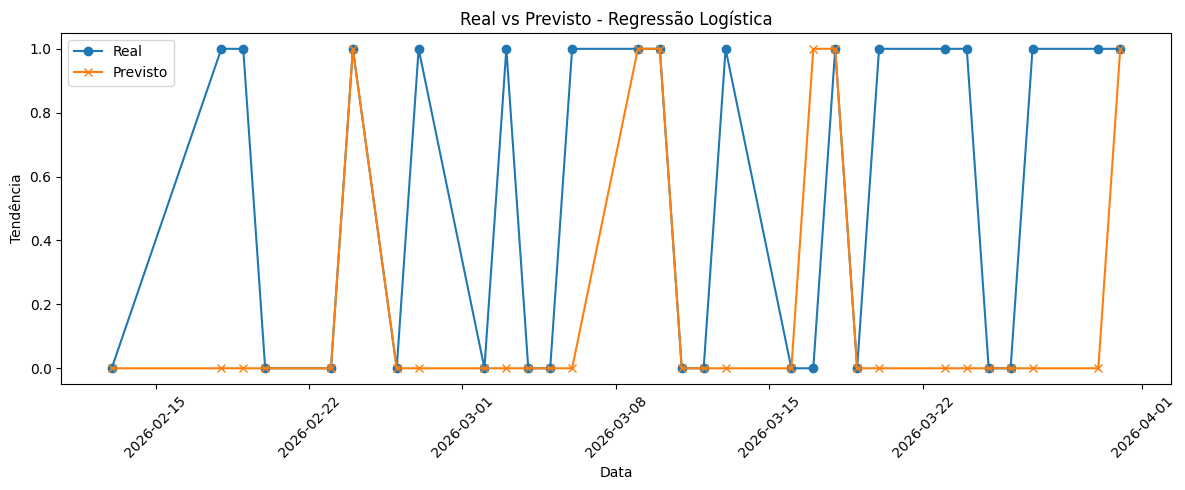

In [ ]:
resultado_plot = test[["data"]].copy()
resultado_plot["real"] = y_test.values
resultado_plot["previsto"] = y_pred_best

plt.figure(figsize=(12, 5))
plt.plot(resultado_plot["data"], resultado_plot["real"], marker="o", label="Real")
plt.plot(resultado_plot["data"], resultado_plot["previsto"], marker="x", label="Previsto")
plt.title(f"Real vs Previsto - {melhor_modelo_nome}")
plt.xlabel("Data")
plt.ylabel("Tendência")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
if melhor_modelo_nome == "Random Forest":
    importancias = pd.Series(melhor_modelo.feature_importances_, index=X_train.columns).sort_values()
    plt.figure(figsize=(8, 6))
    importancias.plot(kind="barh")
    plt.title("Importância das Variáveis - Random Forest")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()

elif melhor_modelo_nome == "XGBoost":
    importancias = pd.Series(melhor_modelo.feature_importances_, index=X_train.columns).sort_values()
    plt.figure(figsize=(8, 6))
    importancias.plot(kind="barh")
    plt.title("Importância das Variáveis - XGBoost")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()

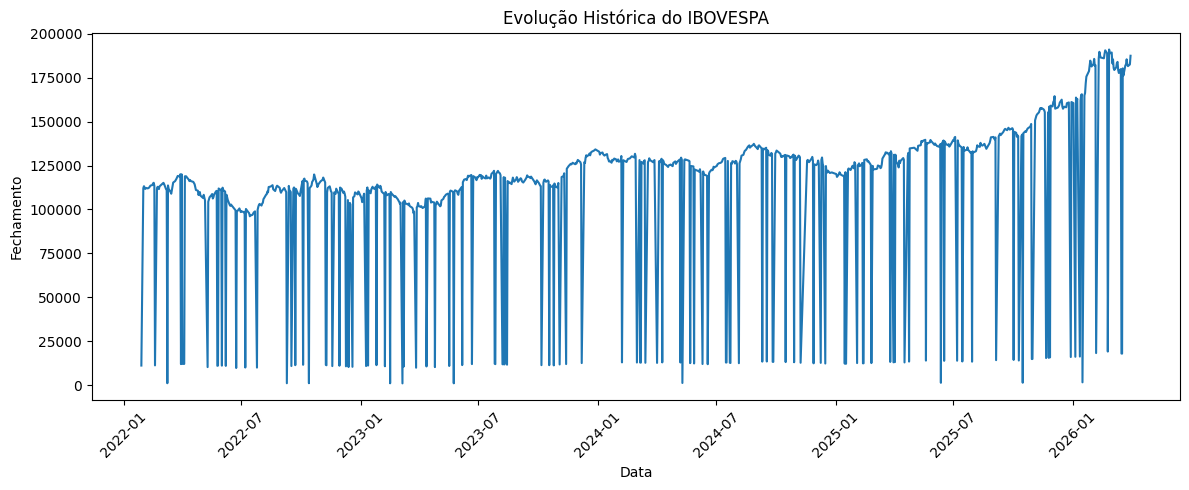

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["ultimo"])
plt.title("Evolução Histórica do IBOVESPA")
plt.xlabel("Data")
plt.ylabel("Fechamento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

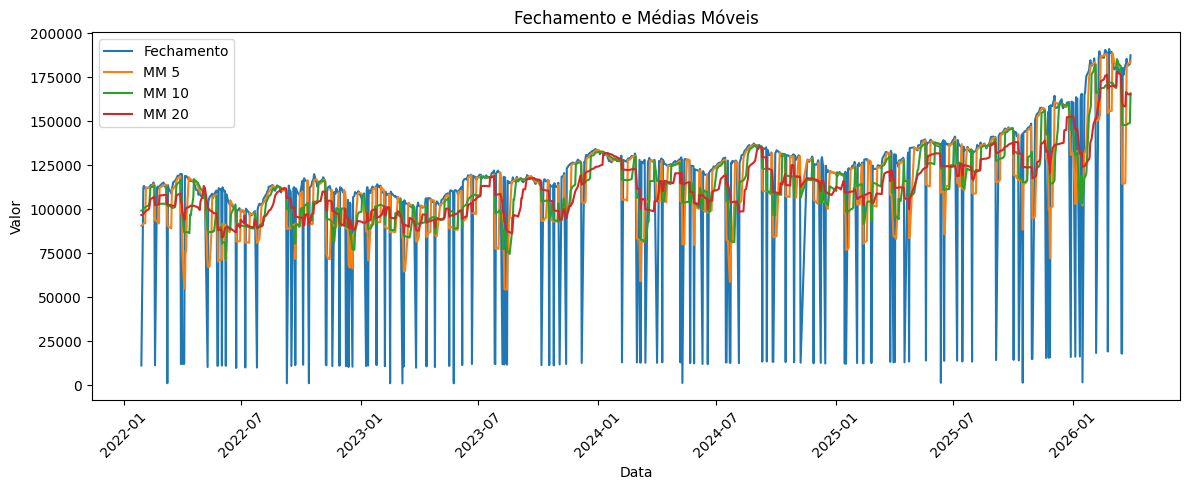

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["ultimo"], label="Fechamento")
plt.plot(df["data"], df["mm_5"], label="MM 5")
plt.plot(df["data"], df["mm_10"], label="MM 10")
plt.plot(df["data"], df["mm_20"], label="MM 20")
plt.title("Fechamento e Médias Móveis")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

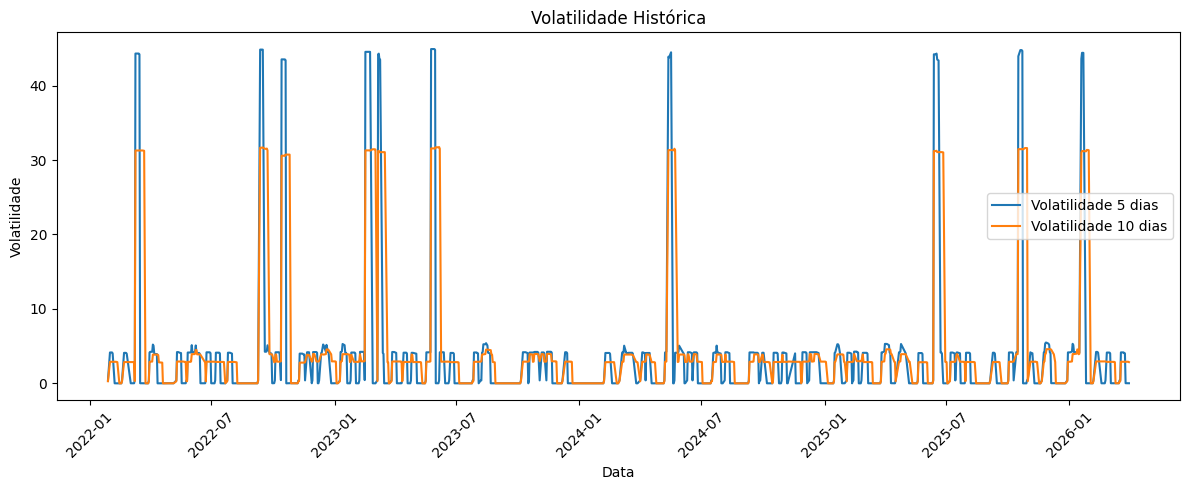

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["data"], df["vol_5"], label="Volatilidade 5 dias")
plt.plot(df["data"], df["vol_10"], label="Volatilidade 10 dias")
plt.title("Volatilidade Histórica")
plt.xlabel("Data")
plt.ylabel("Volatilidade")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

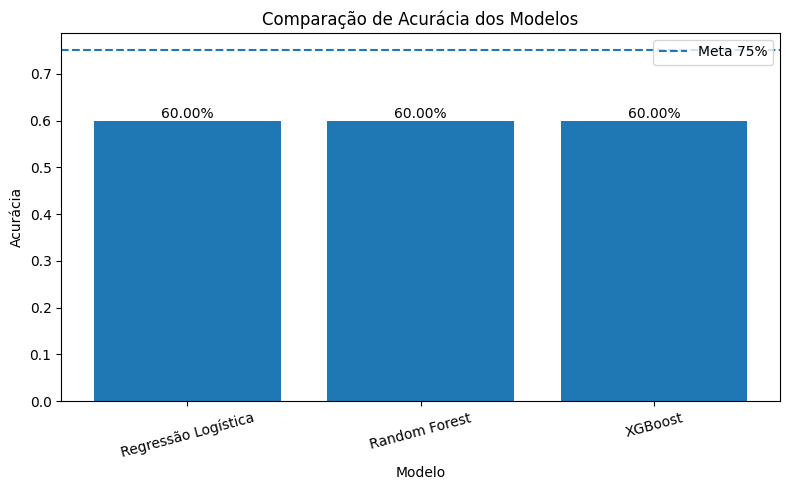

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(df_resultados["Modelo"], df_resultados["Acurácia"])
plt.axhline(0.75, linestyle="--", label="Meta 75%")
plt.title("Comparação de Acurácia dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Acurácia")
plt.xticks(rotation=15)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.005, f"{y:.2%}", ha="center")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
if melhor_modelo_nome == "Random Forest":
    importancias = pd.Series(
        melhor_modelo.feature_importances_,
        index=X_train.columns
    ).sort_values()

    plt.figure(figsize=(8, 6))
    importancias.plot(kind="barh")
    plt.title("Importância das Variáveis - Random Forest")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()

elif melhor_modelo_nome == "XGBoost":
    importancias = pd.Series(
        melhor_modelo.feature_importances_,
        index=X_train.columns
    ).sort_values()

    plt.figure(figsize=(8, 6))
    importancias.plot(kind="barh")
    plt.title("Importância das Variáveis - XGBoost")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()